# 06 - Benchmarking Across Precision Levels (FP16 vs. Q8_0 vs. Q4_K_M)

## Objective
Build a clear, reproducible benchmarking pipeline that ocmpares model quality, speed, and memory across precision levels, then interpret the tradeoffs.

## Key Concepts
- **Quality metrics**: HumanEval pass@1, MBPP pass@1
- **Performance metrics**: tokens/sec, time-to-first-token (TTFT), total latency
- **Resource metrics**: peak RAM usage and model artifact size
- **Trace-off analysis**: where quantization gives "free" wins vs. where it hurts capability

In [1]:
from pathlib import Path
import json

PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR = PROJECT_ROOT / "results"

baseline_path = RESULTS_DIR / "03_baseline_evaluation.json"
ptq_summary_path = RESULTS_DIR / "05_ptq_artifacts_summary.json"

required_paths = [baseline_path, ptq_summary_path]
missing = [str(p) for p in required_paths if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Missing required input files for notebook 06:\n"
        + "\n".join(f"- {m}" for m in missing)
        + "\n\nRun the earlier notebooks (03 and 05) first."
    )

with open(baseline_path,"r") as f:
    baseline = json.load(f)

with open(ptq_summary_path,"r") as f:
    ptq = json.load(f)

artifacts = ptq["artifacts"]

benchmark_manifest = {
    "fp16": {
        "label": "FP16 (reference)",
        "artifact_path": artifacts["f16_source"]["path"],
        "artifact_exists": artifacts["f16_source"]["exists"],
        "artifact_size_gib": artifacts["f16_source"]["size_gib_binary"],
        "baseline_humaneval_pass1": baseline["summary"]["pass_at_1_percent"],
    },
    "q8_0": {
        "label": "Q8_0",
        "artifact_path": artifacts["q8_0"]["path"],
        "artifact_exists": artifacts["q8_0"]["exists"],
        "artifact_size_gib": artifacts["q8_0"]["size_gib_binary"],
        "baseline_humaneval_pass1": None, # to be measured in this notebook
    },
    "q4_k_m": {
        "label": "Q4_K_M",
        "artifact_path": artifacts["q4_k_m"]["path"],
        "artifact_exists": artifacts["q4_k_m"]["exists"],
        "artifact_size_gib": artifacts["q4_k_m"]["size_gib_binary"],
        "baseline_humaneval_pass1": None, # to be measured in this notebook
    },
}

print("Loaded benchmark manifest:")
for key, cfg in benchmark_manifest.items():
    print(
        f"- {cfg['label']}: "
        f"size={cfg['artifact_size_gib']:.2f} GiB, "
        f"exists={cfg['artifact_exists']}, "
        f"path={cfg['artifact_path']}"
    )

print("\nFP16 HumanEval pass@1 baseline from Notebook 03:")
print(f" {benchmark_manifest['fp16']['baseline_humaneval_pass1']:.2f}%")

Loaded benchmark manifest:
- FP16 (reference): size=29.27 GiB, exists=True, path=/Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-F16.gguf
- Q8_0: size=15.56 GiB, exists=True, path=/Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-Q8_0.gguf
- Q4_K_M: size=9.66 GiB, exists=True, path=/Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-Q4_K_M.gguf

FP16 HumanEval pass@1 baseline from Notebook 03:
 60.37%


Next step: Define benchmark result schema.
Create a single, consistent data structure we'll fill in as we run benchmarks.

In [2]:
from datetime import datetime, timezone
from pathlib import Path
import json

RUN_ID = datetime.now(timezone.utc).strftime("%Y%md%dT%H%M%SZ")

BENCHMARK_CONFIG = {
    "run_id": RUN_ID,
    "notebook": "06_benchmarking",
    "hardware": "Apple M4 Max, 64GB RAM",
    "model_id": "deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct",
    "precision_levels": ["fp16", "q8_0", "q4_k_m"],
    "notes": [
        "FP16 HumanEval baseline imported from notebook 03",
        "Q8_0 and Q4_K_M artifacts imported from notebook 05",
        "All new measurements in this notebook should be added under 'measurements'",
    ],
}

def empty_measurement_record():
    return {
        "quality": {
            "humaneval_pass_at_1_percent": None,
            "mbpp_pass_at_1_percent": None,
        },
        "performance": {
            "tokens_per_sec_mean": None,
            "tokens_per_sec_std": None,
            "ttft_sec_mean": None,
            "total_latency_sec_mean": None,
            "n_samples": None,
        },
        "memory": {
            "peak_rss_gib": None,
        },
        "status": "pending",
        "notes": [],
    }

benchmark_results = {
    "metadata": BENCHMARK_CONFIG,
    "artifacts": {
        k: {
            "label": v["label"],
            "artifact_path": v["artifact_path"],
            "artifact_size_gib": v["artifact_size_gib"],
        }
        for k, v in benchmark_manifest.items()
    },
    "measurements": {
        "fp16": empty_measurement_record(),
        "q8_0": empty_measurement_record(),
        "q4_k_m": empty_measurement_record(),
    },
}

benchmark_results["measurements"]["fp16"]["quality"]["humaneval_pass_at_1_percent"] = (
    benchmark_manifest["fp16"]["baseline_humaneval_pass1"]
)

print("Benchmark schema intialized.")
print(f"Run ID: {RUN_ID}")
print("Seeded values:")
print(
    "  FP16 HumanEval pass@1 = "
    f"{benchmark_results['measurements']['fp16']['quality']['humaneval_pass_at_1_percent']:.2f}%"
)
print("\nPending Measurements:")
for p in benchmark_results["metadata"]["precision_levels"]:
    print(f"  - {p}: status={benchmark_results['measurements'][p]['status']}")

Benchmark schema intialized.
Run ID: 202604d06T025654Z
Seeded values:
  FP16 HumanEval pass@1 = 60.37%

Pending Measurements:
  - fp16: status=pending
  - q8_0: status=pending
  - q4_k_m: status=pending


Next step: build latency/throughput measurement harness for GGUF models.
Core concept: define reusable functions to measure TTFT + decode throughput consistently.

In [3]:
import time
import statistics
from typing import List, Dict, Any

try:
    import psutil
except ImportError:
    psutil = None

from llama_cpp import Llama

BENCH_PROMPTS = [
    "Write a Python function `is_prime(n:int) -> bool` with type hints and docstring.",
    "Implement `merge_intervals(intervals)` in Python and explain edge cases briefly.",
    "Given a list of integers, return the longest increasing subsequence length in Python.",
]

def _count_tokens(llm: Llama, text: str) -> int:
    if not text:
        return 0
    return len(llm.tokenize(text.encode("utf-8"), add_bos=False))

def run_streamed_trial(
        llm: Llama,
        prompt: str,
        max_tokens: int = 128,
        temperature: float = 0.0,
) -> Dict[str, Any]:
    """
    Measures:
        - ttft_sec: time-to-first-token
        - decode_tokens_per_sec: generated tokens / decode window
        - total_latency_sec: end-to-end generation time
        - generated_tokens
    """
    start = time.perf_counter()
    first_token_time = None
    generated_chunks = []

    stream = llm.create_completion(
        prompt=prompt,
        max_tokens=max_tokens,
        temperature=temperature,
        stream=True,
    )

    for chunk in stream:
        piece = chunk["choices"][0]["text"]
        if piece and first_token_time is None:
            first_token_time = time.perf_counter()
        generated_chunks.append(piece)

    end = time.perf_counter()
    generated_text = "".join(generated_chunks)
    generated_tokens = _count_tokens(llm, generated_text)

    ttft_sec = (first_token_time - start) if first_token_time is not None else None
    total_latency_sec = end - start

    if first_token_time is not None and end > first_token_time and generated_tokens > 0:
        decode_tps = generated_tokens / (end - first_token_time)
    else:
        decode_tps = 0.0
    
    return {
        "ttft_sec": ttft_sec,
        "total_latency_sec": total_latency_sec,
        "decode_tokens_per_sec": decode_tps,
        "generated_tokens": generated_tokens,
        "generated_preview": generated_text[:160],
    }

def summarize_trials(trials: List[Dict[str, Any]]) -> Dict[str, float]:
    ttfts = [t["ttft_sec"] for t in trials if t["ttft_sec"] is not None]
    tps = [t["decode_tokens_per_sec"] for t in trials]
    lat = [t["total_latency_sec"] for t in trials]

    summary = {
        "ttft_sec_mean": statistics.mean(ttfts) if ttfts else None,
        "ttft_sec_std": statistics.pstdev(ttfts) if len(ttfts) > 1 else 0.0 if ttfts else None,
        "tokens_per_sec_mean": statistics.mean(tps),
        "tokens_per_sec_std": statistics.pstdev(lat) if len(lat) > 1 else 0.0,
        "total_latency_sec_mean": statistics.mean(lat),
        "total_latency_sec_std": statistics.pstdev(lat) if len(lat) > 1 else 0.0,
        "n_samples": len(trials),
    }

    if psutil is not None:
        summary["process_rss_gib"] = psutil.Process().memory_info().rss / (1024 ** 3)
    else:
        summary["process_rss_gib"] = None

    return summary

fp16_path = benchmark_results["artifacts"]["fp16"]["artifact_path"]

llm_fp16 = Llama(
    model_path=fp16_path,
    n_ctx=2048,
    n_threads=8,
    n_gpu_layers=-1,
    verbose=False,
)

print("Harness ready.")
print(f"Loaded FP16 model: {fp16_path}")
print(f"Benchmark prompt count: {len(BENCH_PROMPTS)}")
print("No full benchmark run yet; next cell will execute trials and update benchmark_results.")

llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


Harness ready.
Loaded FP16 model: /Users/jarrett/dev/quantization-study/exports/DeepSeek-Coder-V2-Lite-Instruct-F16.gguf
Benchmark prompt count: 3
No full benchmark run yet; next cell will execute trials and update benchmark_results.


Next cell: run FP16 latency/throughput benchmark and record results
Core concept: execute repeated streamed trials for FP16 and update benchmark_results.

In [4]:
N_ROUNDS = 2
MAX_TOKENS = 128.0
TEMPERATURE = 0.0

# warmup (excluded from metrics)
_ = run_streamed_trial(
    llm=llm_fp16,
    prompt=BENCH_PROMPTS[0],
    max_tokens=32,
    temperature=TEMPERATURE,
)

trials_fp16 = []
for r in range(N_ROUNDS):
    for i, prompt in enumerate(BENCH_PROMPTS):
        trial = run_streamed_trial(
            llm=llm_fp16,
            prompt=prompt,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
        )
        trial["round"] = r + 1
        trial["prompt_index"] = i
        trials_fp16.append(trial)

    summary_fp16 = summarize_trials(trials_fp16)

    m = benchmark_results["measurements"]["fp16"]
    m["performance"]["tokens_per_sec_mean"] = summary_fp16["tokens_per_sec_mean"]
    m["performance"]["tokens_per_sec_std"] = summary_fp16["tokens_per_sec_std"]
    m["performance"]["ttft_sec_mean"] = summary_fp16["ttft_sec_mean"]
    m["performance"]["total_latency_sec_mean"] = summary_fp16["total_latency_sec_mean"]
    m["performance"]["n_samples"] = summary_fp16["n_samples"]
    m["memory"]["peak_rss_gib"] = summary_fp16["process_rss_gib"]
    m["status"] = "complete"
    m["notes"].append(
        f"FP16 perf measured with n_ctx=2048, n_threads=8, n_gpu_layers=-1, "
        f"max_tokens={MAX_TOKENS}, prompts={len(BENCH_PROMPTS)}, rounds={N_ROUNDS}"
    )

    print("FP16 benchmark complete.")
    print(f"Samples: {summary_fp16['n_samples']}")
    print(f"TTFT mean (s):              {summary_fp16['ttft_sec_mean']:.4f}")
    print(f"Decode tokens/sec mean:     {summary_fp16['tokens_per_sec_mean']:.2f}")
    print(f"Decode tokens/sec std:      {summary_fp16['tokens_per_sec_std']:.2f}")
    print(f"Total latency mean (s):     {summary_fp16['total_latency_sec_mean']:.4f}")
    print(f"Process RSS (GiB):          {summary_fp16['process_rss_gib']:.2f}" if summary_fp16["process_rss_gib"] is not None else "Process RSS (GiB): psutil not available")

    for idx, t in enumerate(trials_fp16, 1):
        print(
            f"[trial {idx}] ttft={t['ttft_sec']:.4f}s, "
            f"tps={t['decode_tokens_per_sec']:.24}, "
            f"gen_toks={t['generated_tokens']}"
        )

FP16 benchmark complete.
Samples: 3
TTFT mean (s):              0.0461
Decode tokens/sec mean:     74.75
Decode tokens/sec std:      0.05
Total latency mean (s):     1.7678
Process RSS (GiB):          29.45
[trial 1] ttft=0.0131s, tps=76.5710721683233828116499, gen_toks=129
[trial 2] ttft=0.0652s, tps=74.1088501225720932552576, gen_toks=128
[trial 3] ttft=0.0600s, tps=73.5800843883824455815557, gen_toks=129
FP16 benchmark complete.
Samples: 6
TTFT mean (s):              0.0564
Decode tokens/sec mean:     74.74
Decode tokens/sec std:      0.04
Total latency mean (s):     1.7785
Process RSS (GiB):          29.45
[trial 1] ttft=0.0131s, tps=76.5710721683233828116499, gen_toks=129
[trial 2] ttft=0.0652s, tps=74.1088501225720932552576, gen_toks=128
[trial 3] ttft=0.0600s, tps=73.5800843883824455815557, gen_toks=129
[trial 4] ttft=0.0802s, tps=74.3478087033283969731201, gen_toks=129
[trial 5] ttft=0.0640s, tps=73.2569094409566190506666, gen_toks=128
[trial 6] ttft=0.0561s, tps=76.56705382127

Cell 5: Run Q8_0 latency/throughput benchmark and record results.
Core concept: hold benchmark settings fixed, change only precision (Q8_0).

In [5]:
q8_path = benchmark_results["artifacts"]["q8_0"]["artifact_path"]

llm_q8 = Llama(
    model_path=q8_path,
    n_ctx=2048,
    n_threads=8,
    n_gpu_layers=-1,
    verbose=False,
)

# Warmup (excluded)
_ = run_streamed_trial(
    llm=llm_q8,
    prompt=BENCH_PROMPTS[0],
    max_tokens=32,
    temperature=TEMPERATURE,
)

# Benchmark trials
trials_q8 = []
for r in range(N_ROUNDS):
    for i, prompt in enumerate(BENCH_PROMPTS):
        trial = run_streamed_trial(
            llm=llm_q8,
            prompt=prompt,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
        )
        trial["round"] = r + 1
        trial["prompt_index"] = 1
        trials_q8.append(trial)

summary_q8 = summarize_trials(trials_q8)

m = benchmark_results["measurements"]["q8_0"]
m["performance"]["tokens_per_sec_mean"] = summary_q8["tokens_per_sec_mean"]
m["performance"]["tokens_per_sec_std"] = summary_q8["tokens_per_sec_std"]
m["performance"]["ttft_sec_mean"] = summary_q8["ttft_sec_mean"]
m["performance"]["total_latency_sec_mean"] = summary_q8["total_latency_sec_mean"]
m["performance"]["n_samples"] = summary_q8["n_samples"]
m["memory"]["peak_rss_gib"] = summary_q8["process_rss_gib"]
m["status"] = "complete"
m["notes"].append(
    f"Q8_0 perf measured with n_ctx=20248, n_threads=8, n_gpu_layers=-1, "
    f"max_tokens={MAX_TOKENS}, prompts={len(BENCH_PROMPTS)}, rounds={N_ROUNDS}"
)

print("Q8_0 benchmark complete.")
print(f"Samples: {summary_q8['n_samples']}")
print(f"TTFT mean (s):           {summary_q8['ttft_sec_mean']:.4f}")
print(f"Decode tokens/sec mean:  {summary_q8['tokens_per_sec_mean']:.2f}")
print(f"Decode tokens/sec std:   {summary_q8['tokens_per_sec_std']:.2f}")
print(f"Total latency mean (s):  {summary_q8['total_latency_sec_mean']:.4f}")
print(f"Process RSS (GiB):       {summary_q8['process_rss_gib']:.2f}" if summary_q8["process_rss_gib"] is not None else "Process RSS (GiB):    psutil not available")

for idx, t in enumerate(trials_q8, 1):
    print(
        f"[trial {idx}] ttft={t['ttft_sec']:.4f}s, "
        f"tps={t['decode_tokens_per_sec']:.2f}, "
        f"lat={t['total_latency_sec']:.4f}s, "
        f"gen_toks={t['generated_tokens']}"
    )

llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


Q8_0 benchmark complete.
Samples: 6
TTFT mean (s):           0.0505
Decode tokens/sec mean:  114.01
Decode tokens/sec std:   0.04
Total latency mean (s):  1.1794
Process RSS (GiB):       38.82
[trial 1] ttft=0.0089s, tps=115.92, lat=1.1217s, gen_toks=129
[trial 2] ttft=0.0578s, tps=114.72, lat=1.1736s, gen_toks=128
[trial 3] ttft=0.0526s, tps=115.42, lat=1.1703s, gen_toks=129
[trial 4] ttft=0.0729s, tps=110.52, lat=1.2402s, gen_toks=129
[trial 5] ttft=0.0575s, tps=115.44, lat=1.1663s, gen_toks=128
[trial 6] ttft=0.0532s, tps=112.07, lat=1.2043s, gen_toks=129


Cell 6: Benchmark Q4_K_M with cleanup of prior model objects
Core concept: keep settings fixed, switch precision, avoid overlapping model residency.

In [6]:
import gc

# CLeanup previously loaded models to reduce overlap in RSS accounting
for var_name in ["llm_fp16", "llm_q8"]:
    if var_name in globals():
        del globals()[var_name]
gc.collect()

q4_path = benchmark_results["artifacts"]["q4_k_m"]["artifact_path"]

llm_q4 = Llama(
    model_path=q4_path,
    n_ctx=2048,
    n_threads=8,
    n_gpu_layers=-1,
    verbose=False,
)

# Warmup (excluded)
_ = run_streamed_trial(
    llm=llm_q4,
    prompt=BENCH_PROMPTS[0],
    max_tokens=32,
    temperature=TEMPERATURE,
)

trials_q4 = []

for r in range(N_ROUNDS):
    for i, prompt in enumerate(BENCH_PROMPTS):
        trial = run_streamed_trial(
            llm=llm_q4,
            prompt=prompt,
            max_tokens=MAX_TOKENS,
            temperature=TEMPERATURE,
        )
        trial["round"] = r + 1
        trial["prompt_index"] = 1
        trials_q4.append(trial)

summary_q4 = summarize_trials(trials_q4)

m = benchmark_results["measurements"]["q4_k_m"]
m["performance"]["tokens_per_sec_mean"] = summary_q4["tokens_per_sec_mean"]
m["performance"]["tokens_per_sec_std"] = summary_q4["tokens_per_sec_std"]
m["performance"]["ttft_sec_mean"] = summary_q4["ttft_sec_mean"]
m["performance"]["total_latency_sec_mean"] = summary_q4["total_latency_sec_mean"]
m["performance"]["n_samples"] = summary_q4["n_samples"]
m["memory"]["peak_rss_gib"] = summary_q4["process_rss_gib"]
m["status"] = "complete"
m["notes"].append(
    f"Q4_K_M perf measured with n_ctx=2048, n_threads=8, n_gpu_layers=-1, "
    f"max_tokens={MAX_TOKENS}, prompts={len(BENCH_PROMPTS)}, rounds={N_ROUNDS}"
)

print("Q4_K_M benchmark complete.")
print(f"Samples: {summary_q4['n_samples']}")
print(f"TTFT mean (s):          {summary_q4['ttft_sec_mean']:.4f}")
print(f"Decode tokens/sec mean: {summary_q4['tokens_per_sec_mean']:.2f}")
print(f"Decode tokens/sec std:  {summary_q4['tokens_per_sec_std']:.2f}")
print(f"Total latency mean (s): {summary_q4['total_latency_sec_mean']:.4f}")
print(f"Process RSS (GiB):      {summary_q4['process_rss_gib']:.2f}" if summary_q4["process_rss_gib"] is not None else "Process RSS (GiB):     psutil not available")

llama_context: setting new yarn_attn_factor = 1.0000 (mscale == 0.7, mscale_all_dim = 0.7)
llama_context: n_ctx_seq (2048) < n_ctx_train (163840) -- the full capacity of the model will not be utilized


Q4_K_M benchmark complete.
Samples: 6
TTFT mean (s):          0.0415
Decode tokens/sec mean: 137.56
Decode tokens/sec std:  0.02
Total latency mean (s): 0.9769
Process RSS (GiB):      9.44


Cell 7: Compare FP16 vs Q8_0 vs Q4_K_M and visualize trade-offs
Core concept: convert raw measurements into relative speed/latency insights

Benchmark comparison (current run:)
------------------------------------------------------------------------------------------------
Model               Size(GiB)    TTFT(s)      Tok/s   Latency(s)    Speedup            Lat.Red%
------------------------------------------------------------------------------------------------
FP16 (reference)        29.27     0.0564      74.74       1.7785       1.00x       0.0%
Q8_0                    15.56     0.0505     114.01       1.1794       1.53x      33.7%
Q4_K_M                   9.66     0.0415     137.56       0.9769       1.84x      45.1%


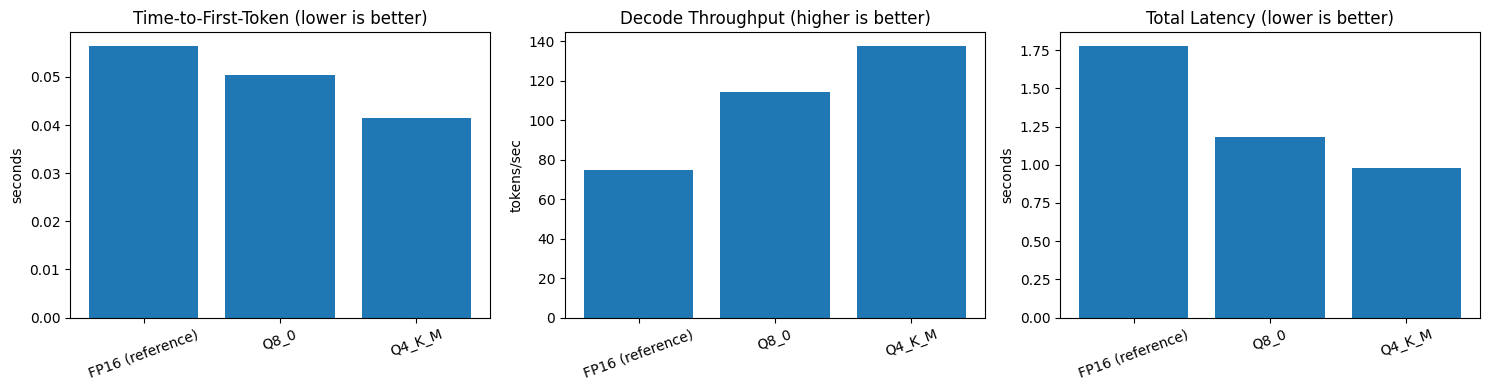


Interpretation notes:
1) TTFT changed modeslty across precisions.
2) Decode throughput and total latency improved strongly from FP16 -> Q8 -> Q4.
3) Peak RSS values are process-level and can be affected by model co-residency in-kernel.


In [8]:
import math
import matplotlib.pyplot as plt

precision_order = ["fp16", "q8_0", "q4_k_m"]
labels = [benchmark_results["artifacts"][p]["label"] for p in precision_order]

def get_metric(p, *keys):
    x = benchmark_results["measurements"][p]
    for k in keys:
        x = x[k]
    return x

fp16_tps = get_metric("fp16", "performance", "tokens_per_sec_mean")
fp16_lat = get_metric("fp16", "performance", "total_latency_sec_mean")
fp16_ttft = get_metric("fp16", "performance", "ttft_sec_mean")

rows = []
for p in precision_order:
    tps = get_metric(p, "performance", "tokens_per_sec_mean")
    lat = get_metric(p, "performance", "total_latency_sec_mean")
    ttft = get_metric(p, "performance", "ttft_sec_mean")
    rss = get_metric(p, "memory", "peak_rss_gib")
    size = benchmark_results["artifacts"][p]["artifact_size_gib"]

    rows.append({
        "precision": p,
        "label": benchmark_results["artifacts"][p]["label"],
        "artifact_size_gib": size,
        "ttft_sec_mean": ttft,
        "tokens_per_sec_mean": tps,
        "total_latency_sec_mean": lat,
        "peak_rss_gib": rss,
        "throughput_speedup_vs_fp16": (tps / fp16_tps) if (tps is not None and fp16_tps) else None,
        "latency_ratio_vs_fp16": (lat / fp16_tps) if (lat is not None and fp16_lat) else None,
        "latency_reduction_vs_fp16_pct": (1 - (lat / fp16_lat)) * 100 if (lat is not None and fp16_lat) else None,
        "ttft_delta_vs_fp16_pct": ((ttft - fp16_ttft) / fp16_ttft) * 100 if (ttft is not None and fp16_ttft) else None,
    })

print("Benchmark comparison (current run:)")
print("-" * 96)
print(f"{'Model':<18} {'Size(GiB)':>10} {'TTFT(s)':>10} {'Tok/s':>10} {'Latency(s)':>12} {'Speedup':>10} {'Lat.Red%':>19}")
print("-" * 96)
for r in rows:
    print(f"{r['label']:<18} "
        f"{r['artifact_size_gib']:>10.2f} "
        f"{r['ttft_sec_mean']:>10.4f} "
        f"{r['tokens_per_sec_mean']:>10.2f} "
        f"{r['total_latency_sec_mean']:>12.4f} "
        f"{r['throughput_speedup_vs_fp16']:>10.2f}x "
        f"{r['latency_reduction_vs_fp16_pct']:>9.1f}%"
    )

# Simple visual comparison
ttfts = [r["ttft_sec_mean"] for r in rows]
tpss = [r["tokens_per_sec_mean"] for r in rows]
lats = [r["total_latency_sec_mean"] for r in rows]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(labels, ttfts)
axes[0].set_title("Time-to-First-Token (lower is better)")
axes[0].set_ylabel("seconds")

axes[1].bar(labels, tpss)
axes[1].set_title("Decode Throughput (higher is better)")
axes[1].set_ylabel("tokens/sec")

axes[2].bar(labels, lats)
axes[2].set_title("Total Latency (lower is better)")
axes[2].set_ylabel("seconds")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("\nInterpretation notes:")
print("1) TTFT changed modeslty across precisions.")
print("2) Decode throughput and total latency improved strongly from FP16 -> Q8 -> Q4.")
print("3) Peak RSS values are process-level and can be affected by model co-residency in-kernel.")

Cell 8: Save benchmark snapshot JSON for downstream notebooks
Core concept: persist reproducible results to results/ with derived comparison metrics.

In [9]:
from pathlib import Path
import json
from datetime import datetime, timezone

RESULTS_DIR = Path("..").resolve() / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def _safe_div(a, b):
    return (a / b) if (a is not None and b not in (None, 0)) else None

fp16 = benchmark_results["measurements"]["fp16"]["performance"]
q8 = benchmark_results["measurements"]["q8_0"]["performance"]
q4 = benchmark_results["measurements"]["q4_k_m"]["performance"]

derived = {
    "speedup_vs_fp16": {
        "q8_0": _safe_div(q8["tokens_per_sec_mean"], fp16["tokens_per_sec_mean"]),
        "q4_k_m": _safe_div(q4["tokens_per_sec_mean"], fp16["tokens_per_sec_mean"]),
    },
    "latency_reduction_vs_fp16_percent": {
        "q8_0": (1 - _safe_div(q8["total_latency_sec_mean"], fp16["total_latency_sec_mean"])) * 100 if _safe_div(q8["total_latency_sec_mean"], fp16["total_latency_sec_mean"]) is not None else None,
        "q4_k_m": (1 - _safe_div(q4["total_latency_sec_mean"], fp16["total_latency_sec_mean"])) * 100 if _safe_div(q4["total_latency_sec_mean"], fp16["total_latency_sec_mean"]) is not None else None,
    },
}

payload = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "06_benchmarking",
    "benchmark_results": benchmark_results,
    "derived_metrics": derived,
}

out_path = RESULTS_DIR / "06_benchmarking_perf_snapshot.json"
with open(out_path, "w") as f:
    json.dump(payload, f, indent=2)

print(f"Saved: {out_path}")
print("Derived metrics:")
print(json.dumps(derived, indent=2))

Saved: /Users/jarrett/dev/quantization-study/results/06_benchmarking_perf_snapshot.json
Derived metrics:
{
  "speedup_vs_fp16": {
    "q8_0": 1.525490937204642,
    "q4_k_m": 1.8405039455656649
  },
  "latency_reduction_vs_fp16_percent": {
    "q8_0": 33.685544664856145,
    "q4_k_m": 45.06818601498001
  }
}
